# Relative Abundance of WS/DGAT Homologs in Marine Sediment Metagenomes

**Author:** Virginia Galván, PhD  
**Associated publication:** Galván et al. (2023) *PLOS ONE* — https://doi.org/10.1371/journal.pone.0288509

---

## Biological context

Wax ester synthase / acyl-CoA:diacylglycerol acyltransferase (WS/DGAT) enzymes, encoded by genes carrying the Pfam domain **PF03007**, catalyze the biosynthesis of neutral lipids (wax esters and triacylglycerols) in bacteria. These compounds function as carbon and energy storage reserves, and are of direct interest for biotechnology applications including biofuel production and oleochemical synthesis.

This notebook quantifies the **relative abundance** of WS/DGAT homologs across 13 marine sediment metagenomes from Subantarctic (Bahía Ushuaia, Argentina) and Antarctic (Potter Cove, King George Island) environments, and tests whether hydrocarbon contamination levels predict biosynthetic potential in these communities.

## Pipeline

```
Metagenome sequences (IMG/M)
        │
        ├── Pfam domain search → WS/DGAT hit count (PF03007)
        └── Pfam domain search → 12 single-copy ribosomal marker gene counts
                │
                ▼
        12 individual ratios: WS/DGAT estimated / marker_i  (i = 1..12)
                │
                ▼
        Relative abundance = mean(12 ratios) ± SD
                │
                ▼
        Statistical analysis + visualization
```

**Input files:**
- `data/Metagenomes_Data_Table.xlsx` — metagenome metadata and hydrocarbon concentrations
- `data/counts_pf03007_and_ribosomal_pfams.xlsx` — individual WS/DGAT / ribosomal marker ratios

## 0. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

# Path configuration: works whether the notebook is run from the repo's
# notebooks/ folder (data/ one level up) or from the same directory as the data files
DATA_DIR = '../data' if os.path.exists('../data') else '.'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 150
})

COLORS = {
    'Subantarctic': '#2E86AB',
    'Antarctic': '#A23B72'
}

print(f'Data directory: {DATA_DIR}')

Data directory: .


## 1. Load data

In [2]:
# Data availability:
# Subtidal metagenomes (ARG01-06, ANT01-06) are publicly available at IMG/M
# (https://img.jgi.doe.gov/) under study 'Marine microbial communities from chronically polluted sediments'
# IMG/M IDs: ARG01=3300000125, ARG02=3300000131, ARG03=3300000121,
#             ARG04=3300000122, ARG05=3300000242, ARG06=3300000118,
#             ANT01=3300000119, ANT02=3300000136, ANT03=3300000135,
#             ANT04=3300000129, ANT05=3300000132, ANT06=3300000123
# OR07: in-house library (raw data not public). WS/DGAT sequences deposited in GenBank: OP731433-OP731569

# --- Metagenome metadata ---
df_meta = pd.read_excel(f'{DATA_DIR}/Metagenomes_Data_Table.xlsx',
                         sheet_name='metagenome_metadata')
df_meta = df_meta.dropna(subset=['metagenome_id', 'region', 'site'])

# OR07 hydrocarbon value is expressed in µg/g dry sediment (all others: wet sediment)
# The '*' flag is removed here; OR07 is excluded from the Spearman correlation (see Section 3.2)
df_meta['total_hydrocarbons_ug_gws'] = pd.to_numeric(
    df_meta['total_hydrocarbons_ug_gws'].astype(str)
    .str.replace('*', '', regex=False).str.strip(),
    errors='coerce'
)

# --- Individual WS/DGAT / ribosomal marker ratios ---
# Row 0 = header (pfam_id + metagenome IDs); rows 1-12 = 12 marker ratios
# Rows 14-15 (Mean, SD) are excluded: we recompute them directly from the data
ratios_raw = pd.read_excel(f'{DATA_DIR}/counts_pf03007_and_ribosomal_pfams.xlsx',
                            sheet_name='WS_DGAT_ribosomal_ratios',
                            header=0, nrows=12)
ratios_raw = ratios_raw.rename(columns={'pfam_id': 'pfam'})

# Reshape to tidy (long) format: one row per pfam-metagenome pair
ratios_long = ratios_raw.melt(id_vars='pfam', var_name='metagenome_id', value_name='ratio')
ratios_long['ratio'] = pd.to_numeric(ratios_long['ratio'], errors='coerce')

# --- Compute relative abundance: mean and SD of the 12 ratios per metagenome ---
stats_computed = (
    ratios_long
    .groupby('metagenome_id')['ratio']
    .agg(relative_abundance_mean='mean', relative_abundance_sd='std')
    .reset_index()
)

# --- Merge metadata with computed abundance stats ---
df_meta = df_meta.drop(columns=['relative_abundance_mean', 'relative_abundance_sd'], errors='ignore')
df = df_meta.merge(stats_computed, on='metagenome_id', how='left')

print(f'Metagenomes loaded: {len(df)}')
print(f'Ribosomal markers used: {ratios_long["pfam"].nunique()}')
print()
df[['metagenome_id', 'region', 'site', 'relative_abundance_mean', 'relative_abundance_sd']].round(3)

Metagenomes loaded: 13
Ribosomal markers used: 12



,metagenome_id,region,site,relative_abundance_mean,relative_abundance_sd
0,ARG01,Subantarctic,MC,1.782,0.257
1,ARG02,Subantarctic,MC,1.937,0.326
2,ARG03,Subantarctic,MC,1.901,0.291
3,ARG04,Subantarctic,OR,0.897,0.162
4,ARG05,Subantarctic,OR,1.265,0.167
5,ARG06,Subantarctic,OR,1.188,0.168
6,OR07,Subantarctic,OR,1.424,0.181
7,ANT01,Antarctic,S1,0.947,0.102
8,ANT02,Antarctic,S1,0.969,0.123
9,ANT03,Antarctic,S1,1.098,0.150


## 1.1 Sampling sites (Figure 0)

Geographic context for the 13 metagenomes analyzed in this notebook: three sites in Ushuaia Bay, Tierra del Fuego, Argentina (MC subtidal, OR subtidal, and the OR07 intertidal in-house library) and two sites in Potter Cove, 25 de Mayo Island, Antarctica (S1, S2), roughly 2,500 km apart. Coordinates are from Galván et al. (2023), S1 Table. A regional overview (left) is paired with a close-up satellite view of each site (right).

This cell fetches satellite basemap tiles (Esri World Imagery) over the network and will not render in network-restricted environments — run it in Colab or any machine with internet access. Requires `geopandas`, `contextily`, and `shapely`.


In [ ]:
# Only needed once per environment (Colab does not include these by default)
try:
    import geopandas, contextily
except ImportError:
    %pip install -q geopandas contextily shapely
    import geopandas, contextily


In [ ]:
import geopandas as gpd
import contextily as cx
from shapely.geometry import Point

coords = pd.read_csv(f'{DATA_DIR}/local_metagenomes_coordinates_repo1.csv')
coords['region_short'] = coords['region'].apply(
    lambda r: 'Ushuaia Bay, Argentina' if 'Ushuaia' in r else 'Potter Cove, Antarctica'
)

sites_gdf = gpd.GeoDataFrame(
    coords, geometry=gpd.points_from_xy(coords['lon'], coords['lat']), crs='EPSG:4326'
).to_crs(epsg=3857)

region_colors = {'Ushuaia Bay, Argentina': '#e63946', 'Potter Cove, Antarctica': '#3a86ff'}
site_colors = {
    'MC (subtidal)': '#e63946', 'OR (subtidal)': '#f4a300', 'OR (intertidal)': '#7b2d8e',
    'S1 (subtidal)': '#3a86ff', 'S2 (subtidal)': '#2ec4b6',
}

fig = plt.figure(figsize=(14, 11))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.3], hspace=0.15, wspace=0.08)
ax_overview = fig.add_subplot(gs[:, 0])
ax_ushuaia = fig.add_subplot(gs[0, 1])
ax_antarctica = fig.add_subplot(gs[1, 1])

# Panel 1: regional overview, spanning most of South America down through the Antarctic Peninsula
corners = gpd.GeoDataFrame(geometry=[Point(-80, -20), Point(-45, -68)], crs='EPSG:4326').to_crs(epsg=3857)
ox1, oy1 = corners.geometry.iloc[0].x, corners.geometry.iloc[0].y
ox2, oy2 = corners.geometry.iloc[1].x, corners.geometry.iloc[1].y
ax_overview.set_xlim(min(ox1, ox2), max(ox1, ox2))
ax_overview.set_ylim(min(oy1, oy2), max(oy1, oy2))
ax_overview.set_aspect('equal')

for region, group in sites_gdf.groupby('region_short'):
    centroid = group.union_all().centroid
    ax_overview.scatter(centroid.x, centroid.y, s=250, color=region_colors[region],
                         edgecolor='black', linewidth=1.5, zorder=5)
    offset = (400000, 250000) if 'Ushuaia' in region else (400000, -350000)
    ax_overview.annotate(region, (centroid.x, centroid.y),
                          xytext=(centroid.x + offset[0], centroid.y + offset[1]),
                          fontsize=12, fontweight='bold', color=region_colors[region], ha='left')
ax_overview.set_title('South America & Antarctica — regional context', fontsize=13)
ax_overview.set_axis_off()

# Panel 2: Ushuaia Bay close-up, one color per site
ushuaia = sites_gdf[sites_gdf['region_short'].str.contains('Ushuaia')]
minx, miny, maxx, maxy = ushuaia.total_bounds
ucx, ucy = (minx + maxx) / 2, (miny + maxy) / 2
ax_ushuaia.set_xlim(ucx - 1500, ucx + 1500)
ax_ushuaia.set_ylim(ucy - 1500, ucy + 1500)
ax_ushuaia.set_aspect('equal')
for site, group in ushuaia.groupby('site'):
    group.plot(ax=ax_ushuaia, color=site_colors[site], markersize=100,
               edgecolor='black', linewidth=1.2, label=site, zorder=5)
ax_ushuaia.legend(fontsize=9, loc='lower right', framealpha=0.9)
ax_ushuaia.set_title('Ushuaia Bay, Tierra del Fuego, Argentina', fontsize=12)
ax_ushuaia.set_axis_off()

# Panel 3: Potter Cove close-up, one color per site
antarctica = sites_gdf[sites_gdf['region_short'].str.contains('Potter')]
minx, miny, maxx, maxy = antarctica.total_bounds
acx, acy = (minx + maxx) / 2, (miny + maxy) / 2
ax_antarctica.set_xlim(acx - 9000, acx + 9000)
ax_antarctica.set_ylim(acy - 9000, acy + 9000)
ax_antarctica.set_aspect('equal')
for site, group in antarctica.groupby('site'):
    group.plot(ax=ax_antarctica, color=site_colors[site], markersize=100,
               edgecolor='black', linewidth=1.2, label=site, zorder=5)
ax_antarctica.legend(fontsize=9, loc='lower right', framealpha=0.9)
ax_antarctica.set_title('Potter Cove, 25 de Mayo Island, Antarctica', fontsize=12)
ax_antarctica.set_axis_off()

cx.add_basemap(ax_overview, crs=sites_gdf.crs, source=cx.providers.Esri.WorldImagery)
cx.add_basemap(ax_ushuaia, crs=sites_gdf.crs, source=cx.providers.Esri.WorldImagery)
cx.add_basemap(ax_antarctica, crs=sites_gdf.crs, source=cx.providers.Esri.WorldImagery)

plt.suptitle('Sampling sites — 13 local metagenomes (Notebook 01)', fontsize=15)
plt.savefig('fig0_sampling_sites_map.png', dpi=300, bbox_inches='tight')
plt.savefig('fig0_sampling_sites_map.svg', bbox_inches='tight')
plt.show()


## 2. Figure 1 — Relative abundance across environments

Mean ± SD of the 12 WS/DGAT / ribosomal marker ratios per metagenome.  
The dashed line at y = 1 marks the threshold where WS/DGAT copy number equals the average single-copy ribosomal gene count (approximately one WS/DGAT gene per genome equivalent in the community).

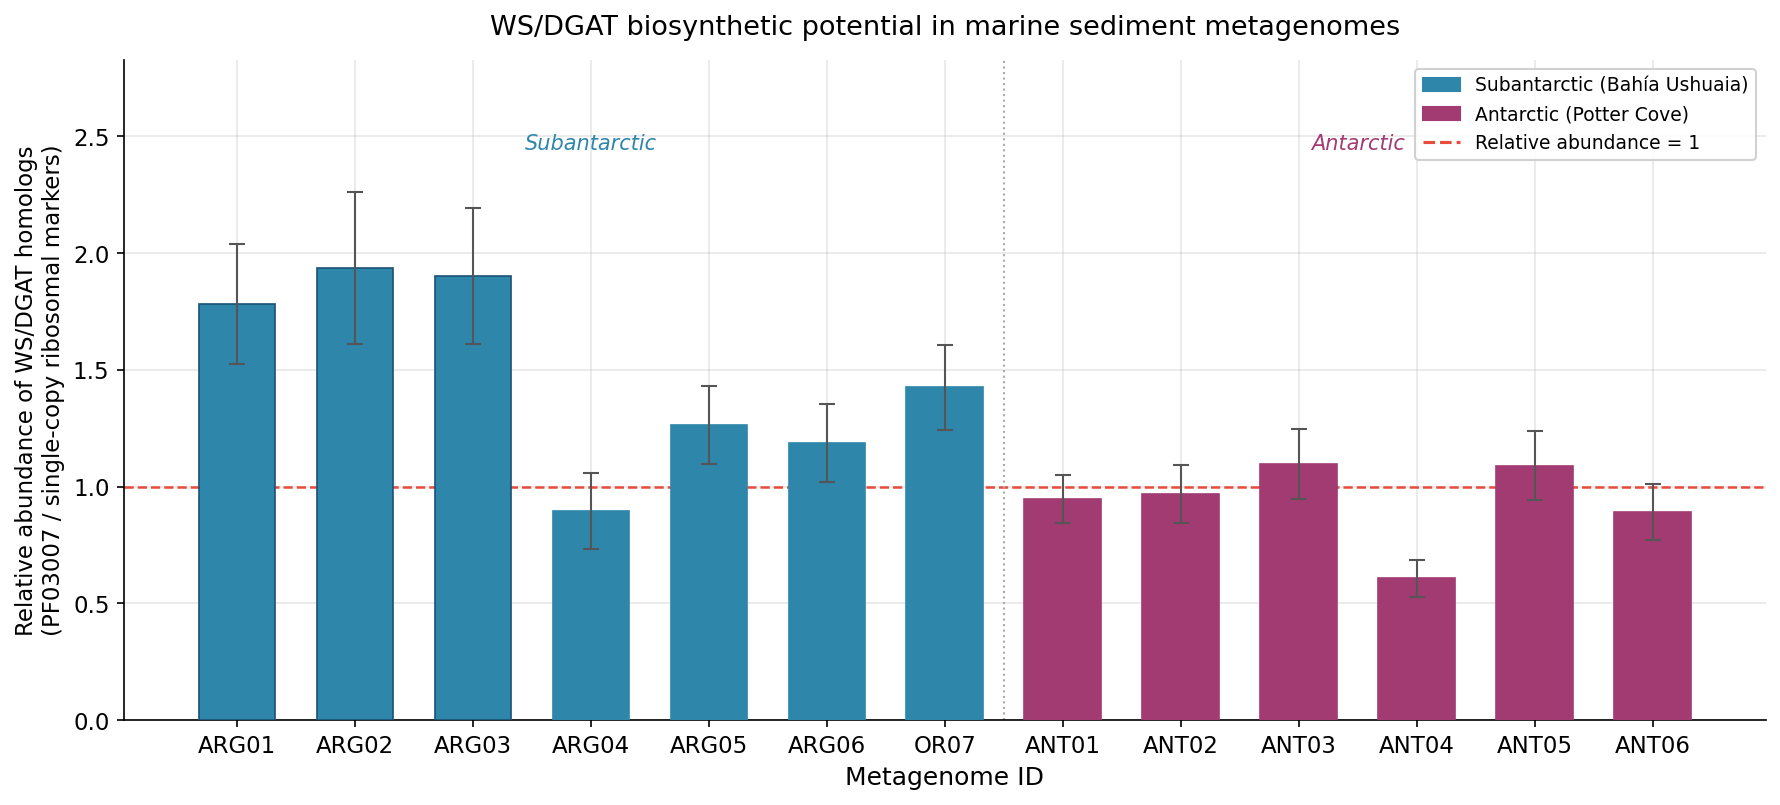

In [3]:
edge_colors = {'MC': '#1a5276', 'OR': '#2E86AB', 'S1': '#A23B72'}
ymax = (df['relative_abundance_mean'] + df['relative_abundance_sd']).max()

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.bar(
    df['metagenome_id'],
    df['relative_abundance_mean'],
    yerr=df['relative_abundance_sd'],
    color=[COLORS[r] for r in df['region']],
    edgecolor=[edge_colors[s] for s in df['site']],
    linewidth=0.8,
    capsize=4,
    error_kw={'elinewidth': 1, 'ecolor': '#555555'},
    width=0.65,
    zorder=3
)

ax.axhline(y=1, color='#E74C3C', linestyle='--', linewidth=1.2, zorder=2)
ax.axvline(x=6.5, color='#AAAAAA', linestyle=':', linewidth=1, zorder=2)

ax.text(3, ymax * 1.08, 'Subantarctic', ha='center', fontsize=10,
        color='#2E86AB', fontstyle='italic')
ax.text(9.5, ymax * 1.08, 'Antarctic', ha='center', fontsize=10,
        color='#A23B72', fontstyle='italic')

ax.legend(
    handles=[
        mpatches.Patch(color='#2E86AB', label='Subantarctic (Bahía Ushuaia)'),
        mpatches.Patch(color='#A23B72', label='Antarctic (Potter Cove)'),
        plt.Line2D([0], [0], color='#E74C3C', linestyle='--', label='Relative abundance = 1')
    ],
    fontsize=9, loc='upper right', framealpha=0.9
)

ax.set_xlabel('Metagenome ID', fontsize=12)
ax.set_ylabel('Relative abundance of WS/DGAT homologs\n(PF03007 / single-copy ribosomal markers)', fontsize=11)
ax.set_title('WS/DGAT biosynthetic potential in marine sediment metagenomes', fontsize=13, pad=12)
ax.set_ylim(0, ymax * 1.25)

plt.tight_layout()
plt.savefig('fig1_relative_abundance.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Statistical analysis

In [4]:
above_1 = (df['relative_abundance_mean'] > 1).sum()
print(f'Metagenomes with relative abundance > 1: {above_1} / {len(df)} ({above_1/len(df)*100:.1f}%)')
print()
print('By region:')
print(df.groupby('region')['relative_abundance_mean']
      .agg(['mean', 'std', 'min', 'max']).round(3))
print()
print('By site:')
print(df.groupby('site')['relative_abundance_mean']
      .agg(['mean', 'std', 'count']).round(3))

Metagenomes with relative abundance > 1: 8 / 13 (61.5%)

By region:
               mean    std    min    max
region                                  
Antarctic     0.934  0.180  0.607  1.098
Subantarctic  1.485  0.398  0.897  1.937

By site:
       mean    std  count
site                     
MC    1.873  0.081      3
OR    1.193  0.221      4
S1    0.934  0.180      6


### 3.1 Mann-Whitney U test: MC vs OR sites

Tests whether MC sites (influenced by urban and port activity) show higher WS/DGAT abundance than OR sites (chronic hydrocarbon contamination). Both site groups are Subantarctic subtidal sediments from Bahía Ushuaia.

The test is performed on all 12 individual marker gene ratios per metagenome (n = 36 per group) rather than on metagenome means, maximizing statistical power.

In [5]:
mc_ratios = ratios_long[ratios_long['metagenome_id'].isin(['ARG01', 'ARG02', 'ARG03'])]['ratio']
or_ratios = ratios_long[ratios_long['metagenome_id'].isin(['ARG04', 'ARG05', 'ARG06'])]['ratio']

U, p_mw = stats.mannwhitneyu(mc_ratios, or_ratios, alternative='two-sided')

print('Mann-Whitney U test: MC sites vs OR sites')
print(f'  MC (n={len(mc_ratios)}) — mean: {mc_ratios.mean():.3f} ± {mc_ratios.std():.3f}')
print(f'  OR (n={len(or_ratios)}) — mean: {or_ratios.mean():.3f} ± {or_ratios.std():.3f}')
print(f'  U = {U},  p = {p_mw:.4f}')

Mann-Whitney U test: MC sites vs OR sites
  MC (n=36) — mean: 1.873 ± 0.292
  OR (n=36) — mean: 1.117 ± 0.228
  U = 1287.0,  p = 0.0000


### 3.2 Spearman correlation: hydrocarbon load vs WS/DGAT abundance

OR07 is excluded: its hydrocarbon concentration is expressed in µg/g dry sediment, while all subtidal metagenomes use µg/g wet sediment — making direct comparison inappropriate.

In [6]:
df_subtidal = df[df['metagenome_id'] != 'OR07'].copy()

rho, p_sp = stats.spearmanr(
    df_subtidal['total_hydrocarbons_ug_gws'],
    df_subtidal['relative_abundance_mean']
)

print('Spearman correlation: hydrocarbon load vs WS/DGAT relative abundance')
print(f'  n = {len(df_subtidal)} subtidal metagenomes')
print(f'  ρ = {rho:.4f},  p = {p_sp:.4f}')

Spearman correlation: hydrocarbon load vs WS/DGAT relative abundance
  n = 12 subtidal metagenomes
  ρ = 0.2797,  p = 0.3786


## 4. Figure 2 — WS/DGAT abundance vs hydrocarbon load

X-axis in log scale: hydrocarbon concentrations span three orders of magnitude (0.018–5.484 µg/g wet sediment), making log scale the appropriate representation for this data distribution.

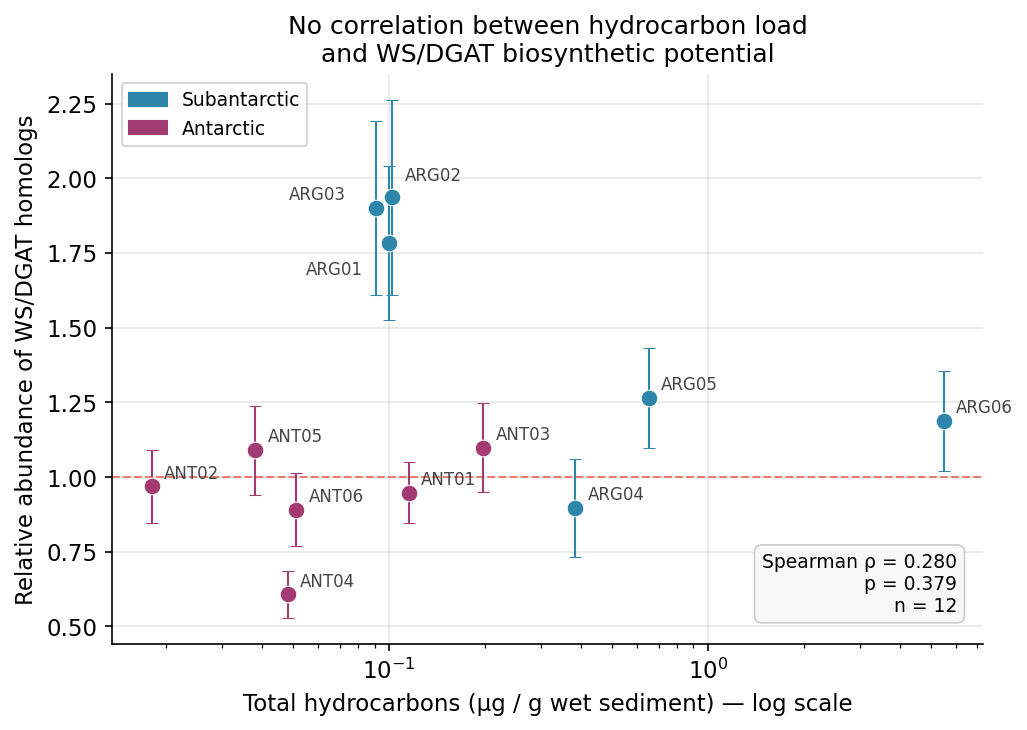

In [7]:
# Manual offsets for closely clustered ARG01-03 labels
label_offsets = {
    'ARG01': (-40, -15),
    'ARG02': (6, 8),
    'ARG03': (-42, 4),
}

fig, ax = plt.subplots(figsize=(7, 5))

for _, row in df_subtidal.iterrows():
    ax.errorbar(
        row['total_hydrocarbons_ug_gws'],
        row['relative_abundance_mean'],
        yerr=row['relative_abundance_sd'],
        fmt='o',
        color=COLORS[row['region']],
        markersize=8, capsize=3, elinewidth=1,
        markeredgecolor='white', markeredgewidth=0.5,
        zorder=3
    )
    offset = label_offsets.get(row['metagenome_id'], (6, 4))
    ax.annotate(
        row['metagenome_id'],
        (row['total_hydrocarbons_ug_gws'], row['relative_abundance_mean']),
        textcoords='offset points', xytext=offset,
        fontsize=8, color='#444444'
    )

ax.axhline(y=1, color='#E74C3C', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xscale('log')

ax.text(0.97, 0.05,
        f'Spearman ρ = {rho:.3f}\np = {p_sp:.3f}\nn = {len(df_subtidal)}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f8f8',
                  edgecolor='#cccccc', linewidth=0.8))

ax.legend(
    handles=[
        mpatches.Patch(color='#2E86AB', label='Subantarctic'),
        mpatches.Patch(color='#A23B72', label='Antarctic')
    ],
    fontsize=9, loc='upper left'
)

ax.set_xlabel('Total hydrocarbons (µg / g wet sediment) — log scale', fontsize=11)
ax.set_ylabel('Relative abundance of WS/DGAT homologs', fontsize=11)
ax.set_title('No correlation between hydrocarbon load\nand WS/DGAT biosynthetic potential', fontsize=12)

plt.tight_layout()
plt.savefig('fig2_spearman_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Summary table

In [8]:
summary = df[['metagenome_id', 'region', 'site', 'matrix',
              'relative_abundance_mean', 'relative_abundance_sd',
              'total_hydrocarbons_ug_gws']].copy()

summary.columns = ['Metagenome', 'Region', 'Site', 'Matrix',
                   'Rel. abundance (mean)', 'Rel. abundance (SD)',
                   'Hydrocarbons (µg/g ws)']

summary[['Rel. abundance (mean)', 'Rel. abundance (SD)']] = \
    summary[['Rel. abundance (mean)', 'Rel. abundance (SD)']].round(3)

display(summary)
summary.to_csv('metagenomes_summary_table.csv', index=False)
print('Exported: metagenomes_summary_table.csv')

,Metagenome,Region,Site,Matrix,Rel. abundance (mean),Rel. abundance (SD),Hydrocarbons (µg/g ws)
0,ARG01,Subantarctic,MC,Subtidal sediments,1.782,0.257,0.100
1,ARG02,Subantarctic,MC,Subtidal sediments,1.937,0.326,0.102
2,ARG03,Subantarctic,MC,Subtidal sediments,1.901,0.291,0.091
3,ARG04,Subantarctic,OR,Subtidal sediments,0.897,0.162,0.383
4,ARG05,Subantarctic,OR,Subtidal sediments,1.265,0.167,0.652
5,ARG06,Subantarctic,OR,Subtidal sediments,1.188,0.168,5.484
6,OR07,Subantarctic,OR,Intertidal sediments,1.424,0.181,NaN
7,ANT01,Antarctic,S1,Subtidal sediments,0.947,0.102,0.115
8,ANT02,Antarctic,S1,Subtidal sediments,0.969,0.123,0.018
9,ANT03,Antarctic,S1,Subtidal sediments,1.098,0.150,0.197


Exported: metagenomes_summary_table.csv


## 6. Key findings

1. **Widespread biosynthetic potential:** 8 of 13 metagenomes (61.5%) show relative WS/DGAT abundance > 1, indicating that neutral lipid biosynthesis genes are at least as prevalent as the average single-copy ribosomal gene in these microbial communities.

2. **Site-dependent differences:** MC sites (Subantarctic, near urban and port activity) showed the highest relative abundances (mean 1.873 ± 0.081), followed by OR subtidal sites (mean 1.157 ± 0.194), while Antarctic S1 sites showed the lowest values (mean 0.934 ± 0.180). The intertidal library OR07 showed a comparable abundance to MC sites (1.42 ± 0.18), consistent with the high microbial activity of the intertidal zone. The Mann-Whitney U test confirmed a significant difference between MC and OR subtidal sites (p < 0.0001, n = 36 ratios per group).

3. **Contamination does not drive abundance:** Spearman correlation between hydrocarbon load and WS/DGAT relative abundance was not statistically significant (ρ = 0.280, p = 0.379, n = 12 subtidal metagenomes), indicating that petroleum contamination level is not the primary determinant of lipid biosynthesis potential in these sediments.


**Biological implication:** These uncultivated marine microbial communities harbor substantial and geographically widespread enzymatic potential for neutral lipid biosynthesis — relevant both for understanding carbon cycling in marine sediments and for the prospection of novel lipid-biosynthetic biocatalysts.

---

## References

- Galván V. et al. (2023). High potential for the biosynthesis of neutral lipid storage compounds in chronically-polluted subantarctic sediments. *PLOS ONE*, 18(7). https://doi.org/10.1371/journal.pone.0288509
- Pfam domain PF03007: https://www.ebi.ac.uk/interpro/entry/pfam/PF03007/